In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/Users/kk5ladybugaol.com/Downloads/usa_00003.csv.gz', low_memory=False)

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

In [ ]:
df = df[df['YEAR'].isin([2019, 2020, 2021, 2022, 2023, 2024])].copy()
print(f"After year filter: {len(df):,} rows")


df = df[df['PERNUM'] == 1].copy()
print(f"After household head filter: {len(df):,} rows")

df = df.drop(columns=['OWNERSHPD', 'RACED', 'HISPAND', 'EDUCD', 'SAMPLE'])
print(f"Columns remaining: {df.columns.tolist()}")

# Filter out group quarters, Handle HHINCOME, Drop remaining nulls in HHINCOME. Create binary ownership variable. Create race/ethnicity variable. Create education categories.
df = df[df['OWNERSHP'].isin([1, 2])].copy()
print(f"After removing group quarters: {len(df):,} rows")

df = df[df['HHINCOME'] != 9999999].copy()

df = df.dropna(subset=['HHINCOME']).copy()
print(f"After income cleaning: {len(df):,} rows")

df['owner'] = (df['OWNERSHP'] == 1).astype(int)
print(f"\nOwnership breakdown:\n{df['owner'].value_counts()}")

conditions = [
    df['HISPAN'] != 0,
    (df['HISPAN'] == 0) & (df['RACE'] == 1),
    (df['HISPAN'] == 0) & (df['RACE'] == 2),
    (df['HISPAN'] == 0) & (df['RACE'] == 6),
]
labels = ['Hispanic', 'White NH', 'Black NH', 'Asian NH']
df['race_eth'] = np.select(conditions, labels, default='Other NH')
print(f"\nRace/ethnicity breakdown:\n{df['race_eth'].value_counts()}")

edu_map = {
    0: 'Less than HS', 1: 'Less than HS', 2: 'Less than HS',
    3: 'Less than HS', 4: 'Less than HS', 5: 'Less than HS',
    6: 'High School',  7: 'Some College', 8: 'Some College',
    9: 'Some College', 10: 'Bachelors',   11: 'Graduate'
}
df['educ_cat'] = df['EDUC'].map(edu_map)

# Post pandemic flag
df['post_pandemic'] = (df['YEAR'] >= 2021).astype(int)


print(f"\nFinal shape: {df.shape}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nSample:\n{df.head()}")

df.to_csv('acs_pums_clean.csv', index=False)
print("\nSaved to acs_pums_clean.csv")

After year filter: 19,335,281 rows
After household head filter: 8,618,102 rows
After removing group quarters: 7,580,554 rows
After income cleaning: 7,580,554 rows

Ownership breakdown:
owner
1    5496324
0    2084230
Name: count, dtype: int64

Race/ethnicity breakdown:
race_eth
White NH    5378405
Hispanic     848623
Black NH     637779
Other NH     455748
Asian NH     259999
Name: count, dtype: int64

Final shape: (7580554, 21)

Null counts:
YEAR             0
SAMPLE           0
SERIAL           0
HHWT             0
STATEFIP         0
OWNERSHP         0
OWNERSHPD        0
HHINCOME         0
PERNUM           0
PERWT            0
AGE              0
RACE             0
RACED            0
HISPAN           0
HISPAND          0
EDUC             0
EDUCD            0
owner            0
race_eth         0
educ_cat         0
post_pandemic    0
dtype: int64

Sample:
          YEAR  SAMPLE  SERIAL   HHWT  STATEFIP  OWNERSHP  OWNERSHPD  \
11648345  2019  201901    2388  370.0         1         1   

In [3]:

print(df['PERNUM'].value_counts().sort_index())

PERNUM
1    7580554
Name: count, dtype: int64


In [4]:
print(df['YEAR'].value_counts().sort_index())

YEAR
2019    1276716
2020    1007437
2021    1281010
2022    1323938
2023    1343045
2024    1348408
Name: count, dtype: int64


/var/folders/0s/mpb3bycx6vl125364q_6_l380000gn/T/ipykernel_46590/530802746.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


   race_eth  own_rate          n
0  White NH  0.730390  5378405.0
1  Black NH  0.441841   637779.0
2  Hispanic  0.505160   848623.0
3  Asian NH  0.608089   259999.0
4  Other NH  0.596137   455748.0


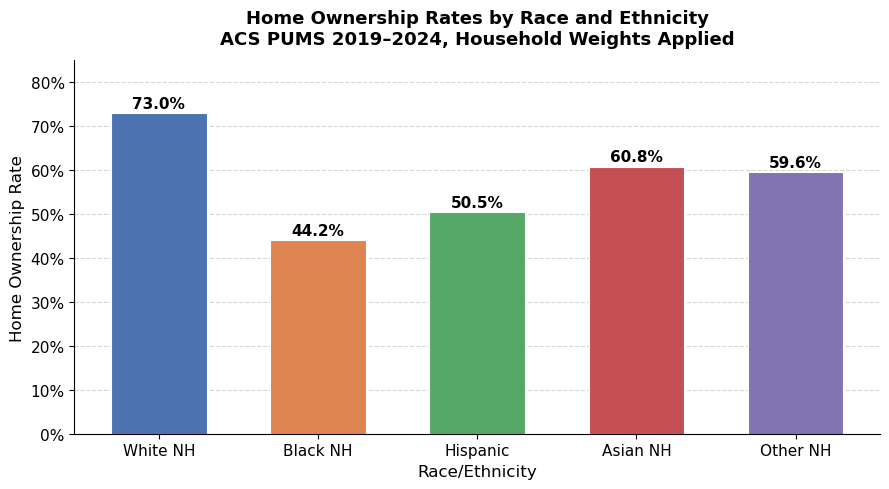

Saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load cleaned data
df = pd.read_csv('acs_pums_clean.csv')

race_order = ['White NH', 'Black NH', 'Hispanic', 'Asian NH', 'Other NH']

weighted_stats = (
    df.groupby('race_eth')
    .apply(lambda g: pd.Series({
        'own_rate': np.average(g['owner'], weights=g['HHWT']),
        'n': len(g)
    }))
    .loc[race_order]  
    .reset_index()
)

print(weighted_stats)


fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

bars = ax.bar(
    weighted_stats['race_eth'],
    weighted_stats['own_rate'],
    color=colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)


for bar, val in zip(bars, weighted_stats['own_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f'{val:.1%}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Formatting
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.85)
ax.set_xlabel('Race/Ethnicity', fontsize=12)
ax.set_ylabel('Home Ownership Rate', fontsize=12)
ax.set_title(
    'Home Ownership Rates by Race and Ethnicity\n'
    'ACS PUMS 2019–2024, Household Weights Applied',
    fontsize=13, fontweight='bold', pad=12
)
ax.tick_params(axis='both', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

# Save
import os
home = os.path.expanduser('~')
plt.savefig(f'{home}/Downloads/fig1_ownership_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Quintile breakdown:
income_quintile
Q1\n(Lowest)     1516304
Q2               1517122
Q3               1526597
Q4               1504885
Q5\n(Highest)    1515646
Name: count, dtype: int64

Ownership rates by quintile and race:
race_eth         White NH  Black NH  Hispanic  Asian NH  Other NH
income_quintile                                                  
Q1\n(Lowest)        0.535     0.268     0.321     0.358     0.383
Q2                  0.657     0.381     0.415     0.483     0.498
Q3                  0.734     0.503     0.519     0.538     0.596
Q4                  0.819     0.646     0.645     0.632     0.703
Q5\n(Highest)       0.882     0.777     0.773     0.783     0.810


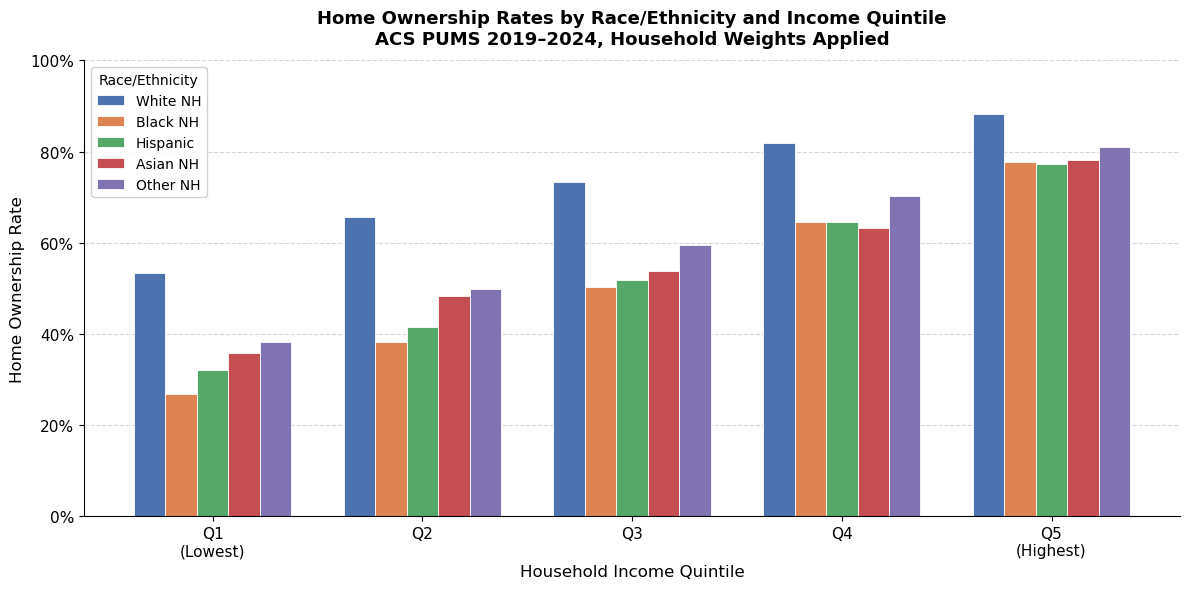

Saved!


In [ ]:
# Create income quintiles
from numpy import percentile

breaks = [0, 20, 40, 60, 80, 100]
labels_q = ['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)']

df['income_quintile'] = pd.qcut(
    df['HHINCOME'],
    q=5,
    labels=labels_q
)


print("Quintile breakdown:")
print(df['income_quintile'].value_counts().sort_index())

# Weighted ownership rate by race × income quintile
grouped = (
    df.groupby(['income_quintile', 'race_eth'], observed=True)
    .apply(lambda g: np.average(g['owner'], weights=g['HHWT']),
           include_groups=False)
    .reset_index()
    .rename(columns={0: 'own_rate'})
)

pivot = grouped.pivot(index='income_quintile', 
                      columns='race_eth', 
                      values='own_rate')

pivot = pivot[race_order]
print("\nOwnership rates by quintile and race:")
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot.index))
n_groups = len(race_order)
bar_width = 0.15
offsets = np.linspace(-bar_width*2, bar_width*2, n_groups)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (race, color) in enumerate(zip(race_order, colors)):
    bars = ax.bar(
        x + offsets[i],
        pivot[race],
        width=bar_width,
        label=race,
        color=color,
        edgecolor='white',
        linewidth=0.6
    )

# Formatting
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=11)
ax.set_xlabel('Household Income Quintile', fontsize=12)
ax.set_ylabel('Home Ownership Rate', fontsize=12)
ax.set_title(
    'Home Ownership Rates by Race/Ethnicity and Income Quintile\n'
    'ACS PUMS 2019–2024, Household Weights Applied',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(
    title='Race/Ethnicity',
    title_fontsize=10,
    fontsize=10,
    loc='upper left',
    framealpha=0.9
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()

# Save
plt.savefig(f'{home}/Downloads/fig2_ownership_race_quintile.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Ownership rates by year and race:
race_eth  White NH  Black NH  Hispanic  Asian NH  Other NH
YEAR                                                      
2019         0.722     0.423     0.481     0.586     0.562
2020         0.731     0.436     0.511     0.595     0.605
2021         0.734     0.442     0.506     0.611     0.600
2022         0.731     0.443     0.511     0.617     0.599
2023         0.732     0.450     0.510     0.616     0.600
2024         0.733     0.455     0.509     0.619     0.599


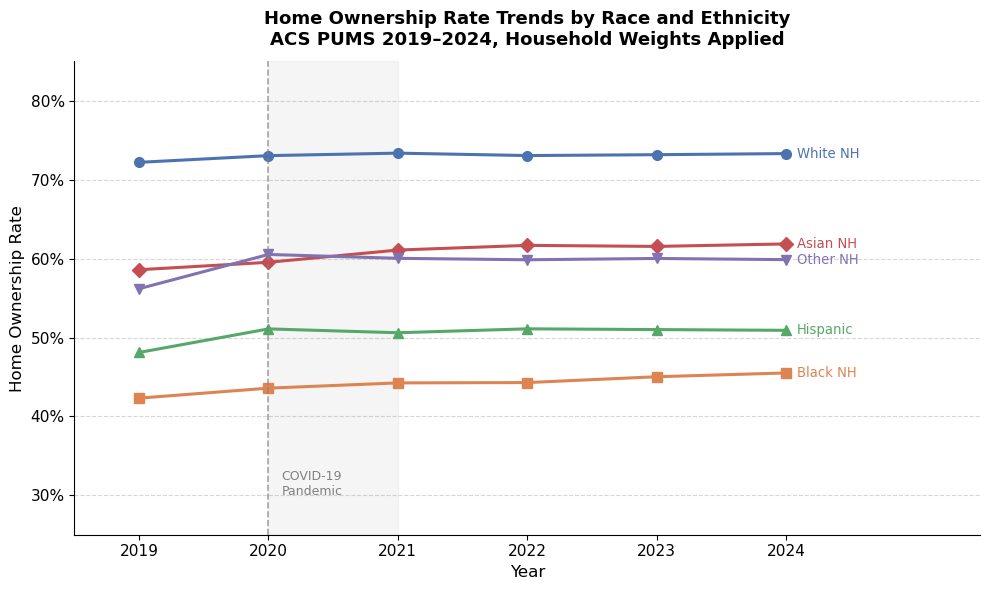

Saved!


In [ ]:
# Weighted ownership rate by race × year
trend = (
    df.groupby(['YEAR', 'race_eth'], observed=True)
    .apply(lambda g: np.average(g['owner'], weights=g['HHWT']),
           include_groups=False)
    .reset_index()
    .rename(columns={0: 'own_rate'})
)

trend_pivot = trend.pivot(index='YEAR', columns='race_eth', values='own_rate')
trend_pivot = trend_pivot[race_order]

print("Ownership rates by year and race:")
print(trend_pivot.round(3))

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
markers = ['o', 's', '^', 'D', 'v']

for race, color, marker in zip(race_order, colors, markers):
    ax.plot(
        trend_pivot.index,
        trend_pivot[race],
        color=color,
        marker=marker,
        linewidth=2.2,
        markersize=7,
        label=race
    )
    
    ax.annotate(
        race,
        xy=(trend_pivot.index[-1], trend_pivot[race].iloc[-1]),
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=9.5,
        color=color,
        va='center'
    )


ax.axvline(x=2020, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2020.1, 0.30, 'COVID-19\nPandemic', fontsize=9, color='gray')

ax.axvspan(2020, 2021, alpha=0.08, color='gray')

# Formatting
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0.25, 0.85)
ax.set_xlim(2018.5, 2025.5)  
ax.set_xticks([2019, 2020, 2021, 2022, 2023, 2024])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Home Ownership Rate', fontsize=12)
ax.set_title(
    'Home Ownership Rate Trends by Race and Ethnicity\n'
    'ACS PUMS 2019–2024, Household Weights Applied',
    fontsize=13, fontweight='bold', pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()


plt.savefig(f'{home}/Downloads/fig3_ownership_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

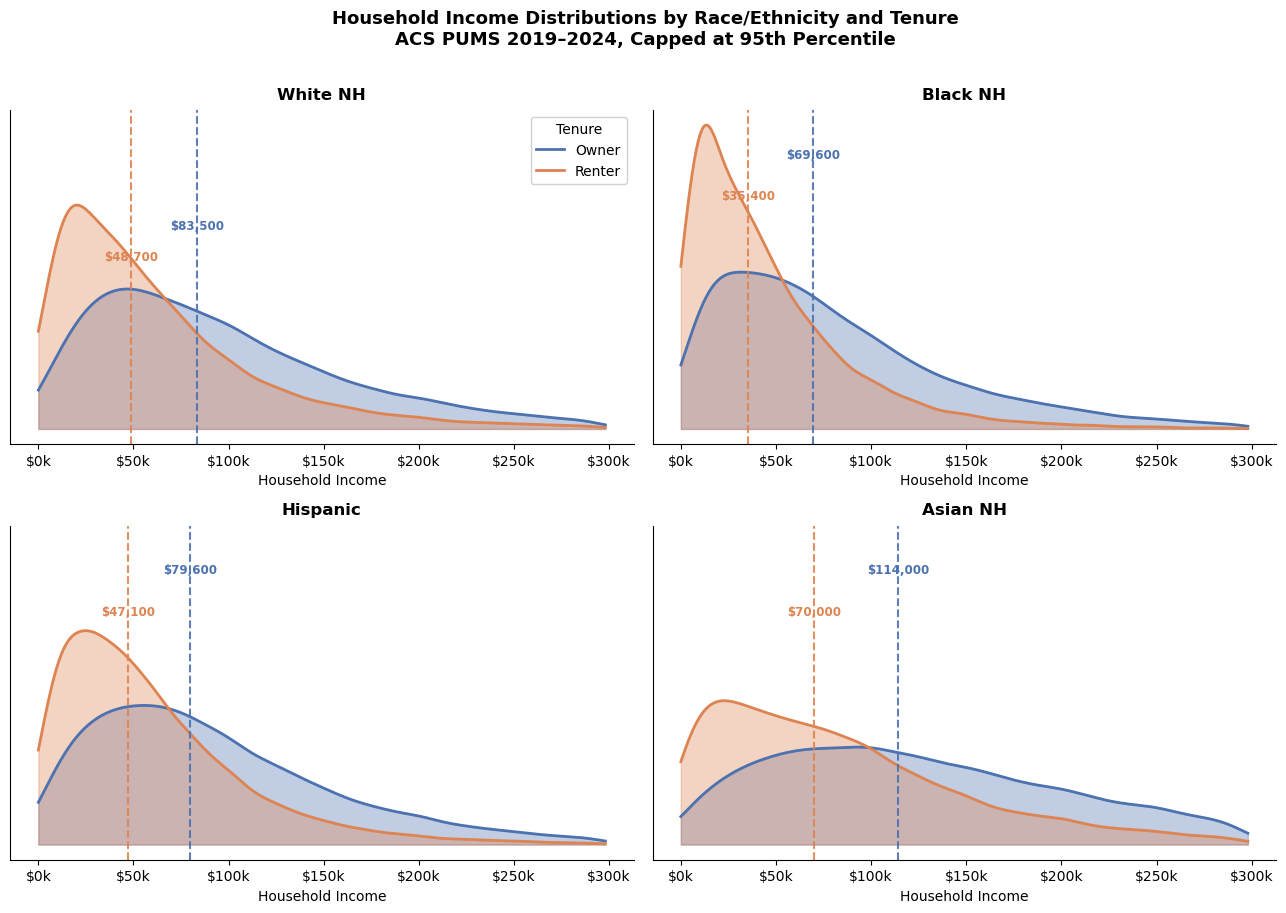

Saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Cap income for readability — 95th percentile
income_cap = df['HHINCOME'].quantile(0.95)
df_plot = df[df['HHINCOME'] <= income_cap].copy()

df_plot['tenure_label'] = df_plot['owner'].map({1: 'Owner', 0: 'Renter'})

groups = ['White NH', 'Black NH', 'Hispanic', 'Asian NH']
df_plot = df_plot[df_plot['race_eth'].isin(groups)].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()

colors = {'Owner': '#4C72B0', 'Renter': '#DD8452'}

for i, race in enumerate(groups):
    ax = axes[i]
    subset = df_plot[df_plot['race_eth'] == race]

    # Get owner and renter income arrays
    owners = subset[subset['tenure_label'] == 'Owner']['HHINCOME']
    renters = subset[subset['tenure_label'] == 'Renter']['HHINCOME']
    owner_wts = subset[subset['tenure_label'] == 'Owner']['HHWT']
    renter_wts = subset[subset['tenure_label'] == 'Renter']['HHWT']

    # Weighted median lines
    def weighted_median(values, weights):
        sorted_idx = np.argsort(values)
        sorted_vals = np.array(values)[sorted_idx]
        sorted_wts = np.array(weights)[sorted_idx]
        cumwt = np.cumsum(sorted_wts)
        cutoff = cumwt[-1] / 2
        return sorted_vals[np.searchsorted(cumwt, cutoff)]

    med_own = weighted_median(owners.values, owner_wts.values)
    med_rent = weighted_median(renters.values, renter_wts.values)

    # KDE plots
    from scipy.stats import gaussian_kde

    for tenure, data, color in [('Owner', owners, '#4C72B0'), 
                                  ('Renter', renters, '#DD8452')]:
        # Sample for KDE speed (max 50k points)
        sample = data.sample(min(50000, len(data)), random_state=42)
        kde = gaussian_kde(sample, bw_method=0.15)
        x_range = np.linspace(0, income_cap, 300)
        kde_vals = kde(x_range)

        ax.fill_between(x_range, kde_vals, alpha=0.35, color=color)
        ax.plot(x_range, kde_vals, color=color, linewidth=2, label=tenure)

    # Median lines
    ax.axvline(med_own, color='#4C72B0', linestyle='--', 
               linewidth=1.5, alpha=0.9)
    ax.axvline(med_rent, color='#DD8452', linestyle='--', 
               linewidth=1.5, alpha=0.9)

    # Median annotations
    ax.text(med_own, ax.get_ylim()[1] * 0.85,
            f'${med_own:,.0f}', color='#4C72B0',
            fontsize=8.5, ha='center', fontweight='bold')
    ax.text(med_rent, ax.get_ylim()[1] * 0.72,
            f'${med_rent:,.0f}', color='#DD8452',
            fontsize=8.5, ha='center', fontweight='bold')

    # Panel formatting
    ax.set_title(race, fontsize=12, fontweight='bold', pad=8)
    ax.xaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_xlabel('Household Income', fontsize=10)

    if i == 0:
        ax.legend(title='Tenure', fontsize=10, 
                  title_fontsize=10, framealpha=0.9)

# Overall title
fig.suptitle(
    'Household Income Distributions by Race/Ethnicity and Tenure\n'
    'ACS PUMS 2019–2024, Capped at 95th Percentile',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()

# Save
plt.savefig(f'{home}/Downloads/fig4_income_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json
import urllib.request

# Weighted ownership rate by state
state_rates = (
    df.groupby('STATEFIP')
    .apply(lambda g: np.average(g['owner'], weights=g['HHWT']),
           include_groups=False)
    .reset_index()
    .rename(columns={0: 'own_rate'})
)

fips_to_abbr = {
    1:'AL', 2:'AK', 4:'AZ', 5:'AR', 6:'CA', 8:'CO', 9:'CT',
    10:'DE', 11:'DC', 12:'FL', 13:'GA', 15:'HI', 16:'ID',
    17:'IL', 18:'IN', 19:'IA', 20:'KS', 21:'KY', 22:'LA',
    23:'ME', 24:'MD', 25:'MA', 26:'MI', 27:'MN', 28:'MS',
    29:'MO', 30:'MT', 31:'NE', 32:'NV', 33:'NH', 34:'NJ',
    35:'NM', 36:'NY', 37:'NC', 38:'ND', 39:'OH', 40:'OK',
    41:'OR', 42:'PA', 44:'RI', 45:'SC', 46:'SD', 47:'TN',
    48:'TX', 49:'UT', 50:'VT', 51:'VA', 53:'WA', 54:'WV',
    55:'WI', 56:'WY'
}

state_rates['abbr'] = state_rates['STATEFIP'].map(fips_to_abbr)
print("State ownership rates:")
print(state_rates.sort_values('own_rate', ascending=False).to_string())

# Plot using plotly for choropleth
import subprocess
subprocess.run(['pip', 'install', 'plotly', 'kaleido', '-q'])

import plotly.graph_objects as go

fig = go.Figure(data=go.Choropleth(
    locations=state_rates['abbr'],
    z=state_rates['own_rate'] * 100,  # convert to percentage
    locationmode='USA-states',
    colorscale=[
        [0.0, '#fff5eb'],
        [0.25, '#fdd0a2'],
        [0.5, '#fd8d3c'],
        [0.75, '#d94801'],
        [1.0, '#7f2704']
    ],
    colorbar=dict(
        title=dict(text='Ownership Rate (%)', font=dict(size=12)),
        ticksuffix='%',
        thickness=18,
        len=0.75
    ),
    zmin=40,
    zmax=80,
))

fig.update_layout(
    title=dict(
        text='Home Ownership Rates by State<br>'
             '<sup>ACS PUMS 2019–2024, Household Weights Applied</sup>',
        x=0.5,
        font=dict(size=16)
    ),
    geo=dict(
        scope='usa',
        projection_type='albers usa',
        showlakes=True,
        lakecolor='rgb(255,255,255)',
        showframe=False,
        coastlinecolor='white',
    ),
    margin=dict(l=20, r=20, t=80, b=20),
    width=950,
    height=550
)



State ownership rates:
    STATEFIP  own_rate abbr
48        54  0.743987   WV
19        23  0.740389   ME
22        26  0.731575   MI
7         10  0.730401   DE
45        50  0.727334   VT
23        27  0.727024   MN
29        33  0.724282   NH
50        56  0.722521   WY
12        16  0.720252   ID
15        19  0.718187   IA
40        45  0.718138   SC
14        18  0.707266   IN
44        49  0.702757   UT
0          1  0.701877   AL
31        35  0.700205   NM
24        28  0.699211   MS
26        30  0.694117   MT
38        42  0.693551   PA
41        46  0.693222   SD
17        21  0.684755   KY
25        29  0.681637   MO
49        55  0.680534   WI
18        22  0.677953   LA
20        24  0.676046   MD
9         12  0.675613   FL
35        39  0.672050   OH
46        51  0.671995   VA
2          4  0.671941   AZ
16        20  0.671872   KS
42        47  0.671726   TN
1          2  0.671172   AK
13        17  0.670991   IL
27        31  0.667486   NE
3          5  0.666963   

/opt/anaconda3/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [10]:
# Fix income quintile labels first
df['income_quintile'] = df['income_quintile'].astype(str).str.replace('\n', ' ')
print(df['income_quintile'].value_counts())

income_quintile
Q3              1526597
Q2              1517122
Q1 (Lowest)     1516304
Q5 (Highest)    1515646
Q4              1504885
Name: count, dtype: int64


In [ ]:
#Linear Regression

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# (White NH = reference)
race_dummies = pd.get_dummies(df['race_eth'], drop_first=False)
race_dummies = race_dummies.drop(columns='White NH').astype(int)

# (Less than HS = reference)
educ_dummies = pd.get_dummies(df['educ_cat'], drop_first=False)
educ_dummies = educ_dummies.drop(columns='Less than HS').astype(int)
# (Q1 = reference)
income_dummies = pd.get_dummies(df['income_quintile'], drop_first=False)
income_dummies = income_dummies.drop(columns='Q1 (Lowest)').astype(int)

# State
state_dummies = pd.get_dummies(
    df['STATEFIP'], prefix='state', drop_first=True).astype(int)

# Other controls
other_vars = df[['AGE', 'post_pandemic']].copy()

# Combine
X = pd.concat([race_dummies, educ_dummies,
               income_dummies, other_vars,
               state_dummies], axis=1)
X = sm.add_constant(X)
y = df['owner']

print(f"Model matrix shape: {X.shape}")
print(f"Outcome variable: {y.value_counts().to_dict()}")

Model matrix shape: (7580554, 65)
Outcome variable: {1: 5496324, 0: 2084230}


In [ ]:
# Normalize weights to avoid overflow
weights = df['HHWT'] / df['HHWT'].mean()

model = sm.Logit(y, X.astype(float))
result = model.fit(
    freq_weights=weights.astype(float),
    maxiter=200,
    method='lbfgs',    
    disp=True
)

print(result.summary2())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           65     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.93147D-01    |proj g|=  1.45674D+01


 This problem is unconstrained.



At iterate    1    f=  5.90451D-01    |proj g|=  5.19126D+00

At iterate    2    f=  5.61734D-01    |proj g|=  1.67975D+00

At iterate    3    f=  5.59229D-01    |proj g|=  4.47439D-01

At iterate    4    f=  5.59054D-01    |proj g|=  2.94953D-02

At iterate    5    f=  5.59030D-01    |proj g|=  6.66325D-02

At iterate    6    f=  5.58957D-01    |proj g|=  1.77530D-01

At iterate    7    f=  5.58622D-01    |proj g|=  5.02557D-01

At iterate    8    f=  5.57899D-01    |proj g|=  9.32056D-01

At iterate    9    f=  5.55923D-01    |proj g|=  1.65304D+00

At iterate   10    f=  5.51367D-01    |proj g|=  2.61736D+00

At iterate   11    f=  5.42094D-01    |proj g|=  3.53125D+00

At iterate   12    f=  5.28868D-01    |proj g|=  3.42812D+00

At iterate   13    f=  5.17484D-01    |proj g|=  1.93629D+00

At iterate   14    f=  5.13645D-01    |proj g|=  4.68948D-01

At iterate   15    f=  5.13317D-01    |proj g|=  3.34274D-02

At iterate   16    f=  5.13292D-01    |proj g|=  1.18274D-01

At iter

In [ ]:
import scipy.stats as stats

# Pull race coefficients manually
race_vars = ['Black NH', 'Hispanic', 'Asian NH', 'Other NH']

print("\n=== RACE/ETHNICITY COEFFICIENTS ===")
print(f"{'Group':<15} {'Coef':>8} {'Std Err':>10} "
      f"{'z':>8} {'p-value':>10} {'Marginal Eff':>14}")
print("-" * 65)

for var in race_vars:
    if var in result.params.index:
        coef = result.params[var]
        se = result.bse[var]
        z = result.tvalues[var]
        p = result.pvalues[var]
        
        mean_xb = result.predict().mean()
        scale = mean_xb * (1 - mean_xb)
        mfx = coef * scale
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else 
                ('*' if p < 0.05 else ''))
        print(f"{var:<15} {coef:>8.3f} {se:>10.3f} "
              f"{z:>8.3f} {p:>10.4f} {mfx:>12.3f} {stars}")

print(f"\nPseudo R-squared (McFadden): {result.prsquared:.4f}")
print(f"Log-likelihood: {result.llf:.1f}")
print(f"N: {len(y):,}")


=== RACE/ETHNICITY COEFFICIENTS ===
Group               Coef    Std Err        z    p-value   Marginal Eff
-----------------------------------------------------------------
Black NH          -0.953      0.003 -300.509     0.0000       -0.190 ***
Hispanic          -0.417      0.003 -139.447     0.0000       -0.083 ***
Asian NH          -0.416      0.005  -85.073     0.0000       -0.083 ***
Other NH          -0.211      0.004  -55.539     0.0000       -0.042 ***

Pseudo R-squared (McFadden): 0.1942
Log-likelihood: -3592238.3
N: 7,580,554


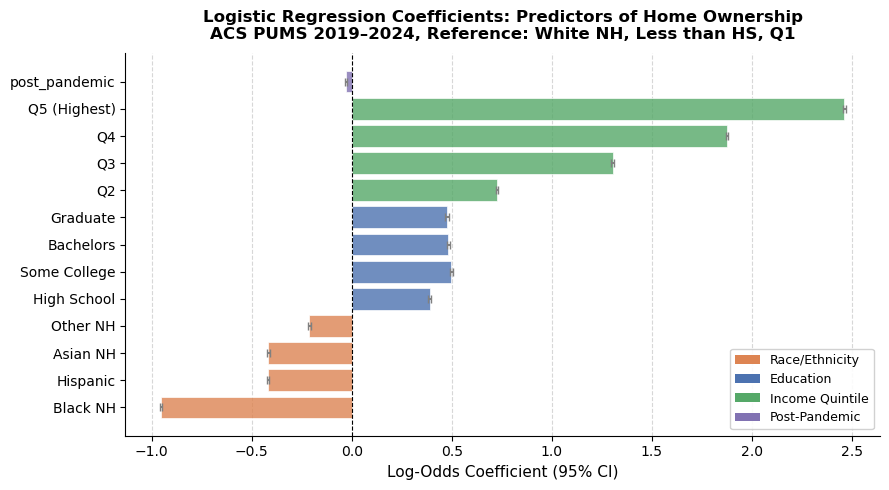

Saved!


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

# Key non-state coefficients to plot
plot_vars = race_vars + ['High School', 'Some College', 
                          'Bachelors', 'Graduate',
                          'Q2', 'Q3', 'Q4', 'Q5 (Highest)',
                          'post_pandemic']

coefs = []
errors = []
labels = []

for var in plot_vars:
    if var in result.params.index:
        coefs.append(result.params[var])
        errors.append(result.bse[var] * 1.96)
        labels.append(var)

colors = ['#DD8452' if v in race_vars else 
          '#4C72B0' if v in ['High School', 'Some College',
                              'Bachelors', 'Graduate'] else
          '#55A868' if 'Q' in v else
          '#8172B2'
          for v in labels]

y_pos = np.arange(len(labels))

ax.barh(y_pos, coefs, xerr=errors, 
        color=colors, alpha=0.8,
        edgecolor='white', linewidth=0.6,
        error_kw=dict(ecolor='gray', capsize=3))

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Log-Odds Coefficient (95% CI)', fontsize=11)
ax.set_title(
    'Logistic Regression Coefficients: Predictors of Home Ownership\n'
    'ACS PUMS 2019–2024, Reference: White NH, Less than HS, Q1',
    fontsize=12, fontweight='bold', pad=10
)

# Add color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#DD8452', label='Race/Ethnicity'),
    Patch(facecolor='#4C72B0', label='Education'),
    Patch(facecolor='#55A868', label='Income Quintile'),
    Patch(facecolor='#8172B2', label='Post-Pandemic')
]
ax.legend(handles=legend_elements, fontsize=9, 
          loc='lower right', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{home}/Downloads/fig6_logit_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [3]:
print(df.columns.tolist())


['YEAR', 'SAMPLE', 'SERIAL', 'HHWT', 'STATEFIP', 'OWNERSHP', 'OWNERSHPD', 'HHINCOME', 'PERNUM', 'PERWT', 'AGE', 'RACE', 'RACED', 'HISPAN', 'HISPAND', 'EDUC', 'EDUCD', 'owner', 'race_eth', 'educ_cat', 'post_pandemic']


In [1]:

#Oaxaca-Blinder

import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

home = os.path.expanduser('~')
df = pd.read_csv('/Users/kk5ladybugaol.com/Downloads/acs_pums_clean.csv')

df['income_quintile'] = pd.qcut(
    df['HHINCOME'],
    q=5,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']
)

print(f"Loaded: {df.shape}")
print(f"\nIncome quintile check:")
print(df['income_quintile'].value_counts().sort_index())
print(f"\nRace/ethnicity check:")
print(df['race_eth'].value_counts())


Loaded: (7580554, 22)

Income quintile check:
income_quintile
Q1 (Lowest)     1516304
Q2              1517122
Q3              1526597
Q4              1504885
Q5 (Highest)    1515646
Name: count, dtype: int64

Race/ethnicity check:
race_eth
White NH    5378405
Hispanic     848623
Black NH     637779
Other NH     455748
Asian NH     259999
Name: count, dtype: int64


White NH: 5,378,405
Black NH: 637,779
Model matrix shape: (6016184, 61)

Fitting White NH model...
White NH R²: 0.1895
Fitting Black NH model...
Black NH R²: 0.2595

OAXACA-BLINDER DECOMPOSITION RESULTS
White NH ownership rate:     73.0%
Black NH ownership rate:     44.2%

Total gap:                   28.9 pp
Explained (characteristics): 9.5 pp [32.9% of gap]
Unexplained (coefficients):  19.4 pp [67.1% of gap]

EXPLAINED COMPONENT BREAKDOWN
--------------------------------------------------
Income:       6.83 pp (23.7% of total gap)
Geography:    -0.71 pp (-2.5% of total gap)
Education:    0.25 pp (0.9% of total gap)
Other:        3.13 pp (10.9% of total gap)


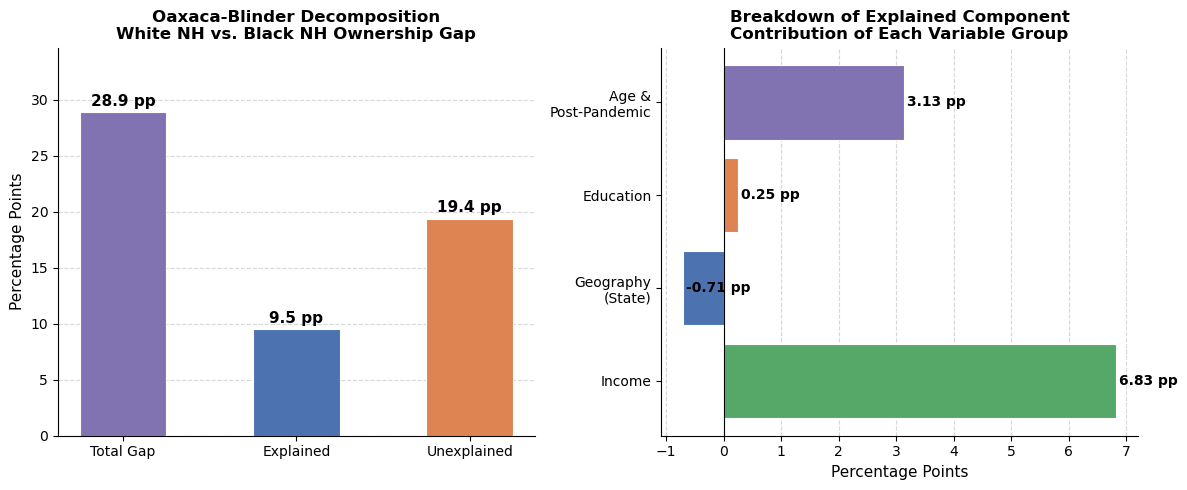

Saved!


In [2]:
# Step 2: Build decomposition dataset
df_ob = df[df['race_eth'].isin(['White NH', 'Black NH'])].copy()
df_ob['white'] = (df_ob['race_eth'] == 'White NH').astype(int)

print(f"White NH: {(df_ob['white']==1).sum():,}")
print(f"Black NH: {(df_ob['white']==0).sum():,}")

# (Less than HS = reference)
educ_dummies = pd.get_dummies(
    df_ob['educ_cat'], drop_first=False).astype(int)
educ_dummies = educ_dummies.drop(columns='Less than HS')

# (Q1 = reference)
income_dummies = pd.get_dummies(
    df_ob['income_quintile'], drop_first=False).astype(int)
income_dummies = income_dummies.drop(columns='Q1 (Lowest)')

# State dummies
state_dummies = pd.get_dummies(
    df_ob['STATEFIP'], prefix='state', drop_first=True).astype(int)

# Other controls
other_vars = df_ob[['AGE', 'post_pandemic']].copy()

# Combine all predictors
X = pd.concat([educ_dummies, income_dummies,
               other_vars, state_dummies], axis=1)
X = sm.add_constant(X)
y = df_ob['owner']
weights = df_ob['HHWT'] / df_ob['HHWT'].mean()

print(f"Model matrix shape: {X.shape}")

# Separate regressions for each group
white_mask = df_ob['white'] == 1
black_mask = df_ob['white'] == 0

X_white = X[white_mask].astype(float)
X_black = X[black_mask].astype(float)
y_white = y[white_mask]
y_black = y[black_mask]
w_white = weights[white_mask]
w_black = weights[black_mask]

print("\nFitting White NH model...")
result_white = sm.WLS(y_white, X_white, 
                       weights=w_white).fit()
print(f"White NH R²: {result_white.rsquared:.4f}")

print("Fitting Black NH model...")
result_black = sm.WLS(y_black, X_black, 
                       weights=w_black).fit()
print(f"Black NH R²: {result_black.rsquared:.4f}")

# Decomposition
X_white_mean = np.average(X_white, weights=w_white, axis=0)
X_black_mean = np.average(X_black, weights=w_black, axis=0)
Y_white_mean = np.average(y_white, weights=w_white)
Y_black_mean = np.average(y_black, weights=w_black)

total_gap = Y_white_mean - Y_black_mean
explained = (X_white_mean - X_black_mean) @ result_white.params
unexplained = X_black_mean @ (result_white.params - result_black.params)

print("\n" + "="*55)
print("OAXACA-BLINDER DECOMPOSITION RESULTS")
print("="*55)
print(f"White NH ownership rate:     {Y_white_mean*100:.1f}%")
print(f"Black NH ownership rate:     {Y_black_mean*100:.1f}%")
print(f"\nTotal gap:                   {total_gap*100:.1f} pp")
print(f"Explained (characteristics): {explained*100:.1f} pp "
      f"[{explained/total_gap*100:.1f}% of gap]")
print(f"Unexplained (coefficients):  {unexplained*100:.1f} pp "
      f"[{unexplained/total_gap*100:.1f}% of gap]")
print("="*55)

# Break down explained component by group
coef_w = result_white.params
diff_X = X_white_mean - X_black_mean
col_names = list(X.columns)

educ_cols = ['High School', 'Some College', 
             'Bachelors', 'Graduate']
income_cols = ['Q2', 'Q3', 'Q4', 'Q5 (Highest)']
state_cols = [c for c in col_names if c.startswith('state')]
other_cols = ['AGE', 'post_pandemic']

def group_contribution(cols):
    total = 0
    for c in cols:
        if c in col_names:
            i = col_names.index(c)
            total += diff_X[i] * coef_w.iloc[i]
    return total

educ_contrib = group_contribution(educ_cols)
income_contrib = group_contribution(income_cols)
state_contrib = group_contribution(state_cols)
other_contrib = group_contribution(other_cols)

print("\nEXPLAINED COMPONENT BREAKDOWN")
print("-"*50)
print(f"Income:       {income_contrib*100:.2f} pp "
      f"({income_contrib/total_gap*100:.1f}% of total gap)")
print(f"Geography:    {state_contrib*100:.2f} pp "
      f"({state_contrib/total_gap*100:.1f}% of total gap)")
print(f"Education:    {educ_contrib*100:.2f} pp "
      f"({educ_contrib/total_gap*100:.1f}% of total gap)")
print(f"Other:        {other_contrib*100:.2f} pp "
      f"({other_contrib/total_gap*100:.1f}% of total gap)")

# Visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Overall decomposition
ax1 = axes[0]
categories = ['Total Gap', 'Explained', 'Unexplained']
values = [total_gap*100, explained*100, unexplained*100]
colors = ['#8172B2', '#4C72B0', '#DD8452']

bars = ax1.bar(categories, values, color=colors,
               width=0.5, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + 0.3,
             f'{val:.1f} pp',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

ax1.set_ylabel('Percentage Points', fontsize=11)
ax1.set_title('Oaxaca-Blinder Decomposition\n'
              'White NH vs. Black NH Ownership Gap',
              fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.set_ylim(0, max(values) * 1.2)

# Plot 2: Explained component breakdown
ax2 = axes[1]
groups = ['Income', 'Geography\n(State)',
          'Education', 'Age &\nPost-Pandemic']
contribs = [income_contrib*100, state_contrib*100,
            educ_contrib*100, other_contrib*100]
colors2 = ['#55A868', '#4C72B0', '#DD8452', '#8172B2']

bars2 = ax2.barh(groups, contribs, color=colors2,
                  edgecolor='white', linewidth=0.8)

for bar, val in zip(bars2, contribs):
    ax2.text(val + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f} pp',
             ha='left', va='center',
             fontsize=10, fontweight='bold')

ax2.set_xlabel('Percentage Points', fontsize=11)
ax2.set_title('Breakdown of Explained Component\n'
              'Contribution of Each Variable Group',
              fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{home}/Downloads/fig7_oaxaca_blinder.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Sample size: 5,950,812
YEAR
2019    1186954
2021    1153575
2022    1191226
2023    1207355
2024    1211702
Name: count, dtype: int64
income_quintile
Q1 (Lowest)     1197451
Q2              1213343
Q3              1207483
Q4              1200749
Q5 (Highest)    1131786
Name: count, dtype: int64
Sample size: 5,950,812
YEAR
2019    1186954
2021    1153575
2022    1191226
2023    1207355
2024    1211702
Name: count, dtype: int64

Fitting DiD model...

DIFFERENCE-IN-DIFFERENCES RESULTS
Post-pandemic effect (White NH):  -0.88 pp
Minority gap (pre-pandemic):      -13.96 pp
Interaction (Post x Minority):    0.65 pp
Standard error:                   0.14 pp
p-value:                          0.0000 ***

DiD BY INCOME QUINTILE
------------------------------------------------------------
Q1 (Lowest)     coef=-0.19 pp  se=0.27  p=0.4677 n.s.
Q2              coef=0.31 pp  se=0.30  p=0.3023 n.s.
Q3              coef=0.47 pp  se=0.34  p=0.1624 n.s.
Q4              coef=-0.67 pp  se=0.37  p=0.0685 n.s

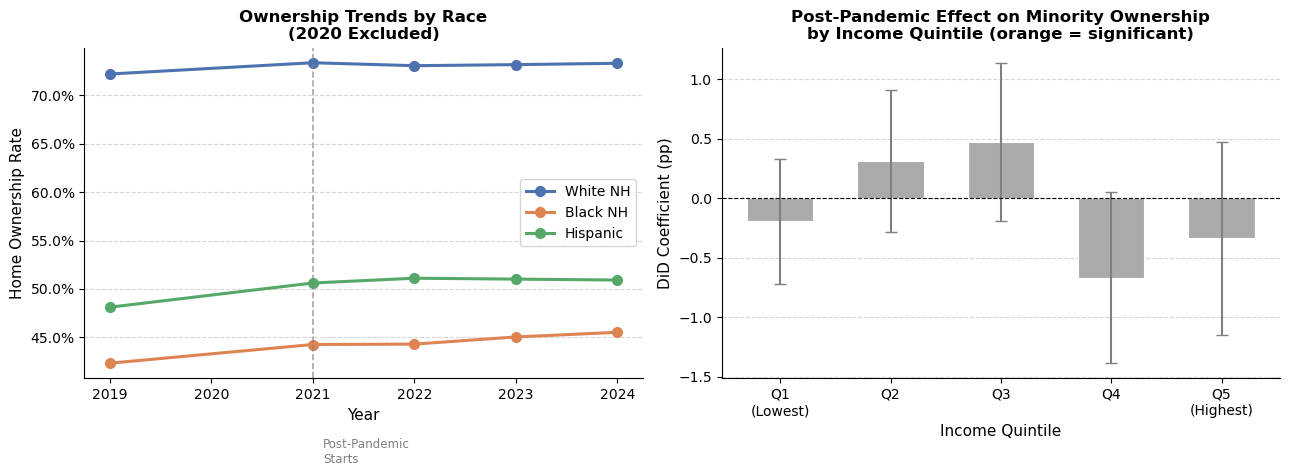

Saved!


In [1]:
#Difference-in-Diffrences

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
df = pd.read_csv('/Users/kk5ladybugaol.com/Downloads/acs_pums_clean.csv')

home = os.path.expanduser('~')

df_did = df[df['YEAR'] != 2020].copy()

df_did['income_quintile'] = pd.qcut(
    df_did['HHINCOME'],
    q=5,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']
)

df_did['minority'] = df_did['race_eth'].isin(
    ['Black NH', 'Hispanic']).astype(int)
df_did = df_did[df_did['race_eth'].isin(
    ['White NH', 'Black NH', 'Hispanic'])].copy()
df_did['post_x_minority'] = (
    df_did['post_pandemic'] * df_did['minority'])

print(f"Sample size: {len(df_did):,}")
print(df_did['YEAR'].value_counts().sort_index())
print(df_did['income_quintile'].value_counts().sort_index())

df_did['minority'] = df_did['race_eth'].isin(
    ['Black NH', 'Hispanic']).astype(int)
df_did = df_did[df_did['race_eth'].isin(
    ['White NH', 'Black NH', 'Hispanic'])].copy()
df_did['post_x_minority'] = (
    df_did['post_pandemic'] * df_did['minority'])

print(f"Sample size: {len(df_did):,}")
print(df_did['YEAR'].value_counts().sort_index())

educ_dummies = pd.get_dummies(
    df_did['educ_cat'], drop_first=False).astype(int)
educ_dummies = educ_dummies.drop(columns='Less than HS')

income_dummies = pd.get_dummies(
    df_did['income_quintile'], drop_first=False).astype(int)
income_dummies = income_dummies.drop(columns='Q1 (Lowest)')

state_dummies = pd.get_dummies(
    df_did['STATEFIP'], prefix='state',
    drop_first=True).astype(int)

did_vars = df_did[['post_pandemic', 'minority',
                    'post_x_minority', 'AGE']].copy()

X_did = pd.concat([did_vars, educ_dummies,
                   income_dummies, state_dummies], axis=1)
X_did = sm.add_constant(X_did)
y_did = df_did['owner']
weights_did = df_did['HHWT'] / df_did['HHWT'].mean()

print(f"\nFitting DiD model...")
result_did = sm.WLS(y_did, X_did.astype(float),
                    weights=weights_did).fit(cov_type='HC1')

post_coef = result_did.params['post_pandemic']
minority_coef = result_did.params['minority']
interaction_coef = result_did.params['post_x_minority']
interaction_se = result_did.bse['post_x_minority']
interaction_p = result_did.pvalues['post_x_minority']

stars = ('***' if interaction_p < 0.001 else
         '**' if interaction_p < 0.01 else
         '*' if interaction_p < 0.05 else 'n.s.')

print("\n" + "="*60)
print("DIFFERENCE-IN-DIFFERENCES RESULTS")
print("="*60)
print(f"Post-pandemic effect (White NH):  {post_coef*100:.2f} pp")
print(f"Minority gap (pre-pandemic):      {minority_coef*100:.2f} pp")
print(f"Interaction (Post x Minority):    {interaction_coef*100:.2f} pp")
print(f"Standard error:                   {interaction_se*100:.2f} pp")
print(f"p-value:                          {interaction_p:.4f} {stars}")
print("="*60)

print("\nDiD BY INCOME QUINTILE")
print("-"*60)
quintile_results = []
for q in ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']:
    mask = df_did['income_quintile'] == q
    df_q = df_did[mask].copy()

    did_vars_q = df_q[['post_pandemic', 'minority',
                         'post_x_minority', 'AGE']].copy()
    educ_q = pd.get_dummies(
        df_q['educ_cat'], drop_first=False).astype(int)
    if 'Less than HS' in educ_q.columns:
        educ_q = educ_q.drop(columns='Less than HS')
    state_q = pd.get_dummies(
        df_q['STATEFIP'], prefix='state',
        drop_first=True).astype(int)

    X_q = pd.concat([did_vars_q, educ_q, state_q], axis=1)
    X_q = sm.add_constant(X_q)
    y_q = df_q['owner']
    w_q = df_q['HHWT'] / df_q['HHWT'].mean()

    try:
        res_q = sm.WLS(y_q, X_q.astype(float),
                        weights=w_q).fit(cov_type='HC1')
        coef = res_q.params.get('post_x_minority', np.nan)
        se = res_q.bse.get('post_x_minority', np.nan)
        pval = res_q.pvalues.get('post_x_minority', np.nan)
        stars_q = ('***' if pval < 0.001 else
                   '**' if pval < 0.01 else
                   '*' if pval < 0.05 else 'n.s.')
        print(f"{q:<15} coef={coef*100:.2f} pp  "
              f"se={se*100:.2f}  p={pval:.4f} {stars_q}")
        quintile_results.append({
            'quintile': q, 'coef': coef,
            'se': se, 'pval': pval
        })
    except Exception as e:
        print(f"{q}: Error — {e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
for group, label, color in [
    ('White NH', 'White NH', '#4C72B0'),
    ('Black NH', 'Black NH', '#DD8452'),
    ('Hispanic', 'Hispanic', '#55A868')
]:
    trend = (
        df_did[df_did['race_eth'] == group]
        .groupby('YEAR')
        .apply(lambda g: np.average(
            g['owner'], weights=g['HHWT']),
               include_groups=False)
        .reset_index()
        .rename(columns={0: 'own_rate'})
    )
    ax1.plot(trend['YEAR'], trend['own_rate'],
             marker='o', linewidth=2.2,
             markersize=7, label=label, color=color)

ax1.axvline(x=2021, color='gray', linestyle='--',
            linewidth=1.2, alpha=0.7)
ax1.text(2021.1, 0.32, 'Post-Pandemic\nStarts',
         fontsize=8.5, color='gray')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Home Ownership Rate', fontsize=11)
ax1.set_title('Ownership Trends by Race\n(2020 Excluded)',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

ax2 = axes[1]
if quintile_results:
    qr = pd.DataFrame(quintile_results)
    short_labels = ['Q1\n(Lowest)', 'Q2', 'Q3',
                    'Q4', 'Q5\n(Highest)']
    colors_q = ['#DD8452' if p < 0.05 else '#aaaaaa'
                for p in qr['pval']]

    ax2.bar(short_labels, qr['coef']*100,
            color=colors_q, width=0.6,
            edgecolor='white', linewidth=0.8)
    ax2.errorbar(short_labels, qr['coef']*100,
                 yerr=qr['se']*100*1.96,
                 fmt='none', color='gray',
                 capsize=4, linewidth=1.5)
    ax2.axhline(0, color='black', linewidth=0.8,
                linestyle='--')
    ax2.set_xlabel('Income Quintile', fontsize=11)
    ax2.set_ylabel('DiD Coefficient (pp)', fontsize=11)
    ax2.set_title(
        'Post-Pandemic Effect on Minority Ownership\n'
        'by Income Quintile (orange = significant)',
        fontsize=12, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{home}/Downloads/fig8_diff_in_diff.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")